In [1]:
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cross_decomposition import PLSCanonical
import umap
import phate

from src import utils
importlib.reload(utils)

<module 'src.utils' from '/Users/yuli/Documents/Code/SphericalHarmonics/src/utils.py'>

In [33]:
path = 'Data'
emb_dir = f"{path}/embeddings"


In [34]:
import os
import pandas as pd

# Load master (shape features only — no fm_coeffs)
master = np.load(f"{path}/master.npz", allow_pickle=True)

filtered_ids      = master['ids'].astype(str)
filtered_datasets = master['datasets'].astype(str)   # dataset name per organoid, no splitting needed
filtered_times    = master['times'].astype(str)
filtered_areas    = master['areas']
l_cross_values    = master['l_cross_values']
filtered_hks      = master['hks_bof_coeffs__kmeans_variable']   # (N, n_modes^2, n_vocab)
# filtered_hks    = master['hks_bof_coeffs__pca_variable']

print('organoids:', len(filtered_ids), '| hks:', filtered_hks.shape)

organoids: 3056 | hks: (3056, 225, 8)


In [35]:
num_degree = int(np.sqrt(filtered_hks.shape[1]))
hks_power_spectrum = np.zeros((filtered_hks.shape[0], num_degree, filtered_hks.shape[2]))

for n in range(num_degree):
    start_idx = n**2
    end_idx = (n+1)**2
    # Sum of squared coefficients between l = n^2 and (n+1)^2
    hks_power_spectrum[:, n, :] = np.sum(filtered_hks[:, start_idx:end_idx, :]**2, axis=1)

print(hks_power_spectrum.shape)

(3056, 15, 8)


In [36]:
hks_power_spectrum /= np.max(hks_power_spectrum, axis=(0,1), keepdims=True)  # Normalize HKS by its maximum value across all samples and degrees
coeffs = hks_power_spectrum

hks_names = [f'hks-{i}' for i in range(hks_power_spectrum.shape[-1])]
names = hks_names
print(names)

['hks-0', 'hks-1', 'hks-2', 'hks-3', 'hks-4', 'hks-5', 'hks-6', 'hks-7']


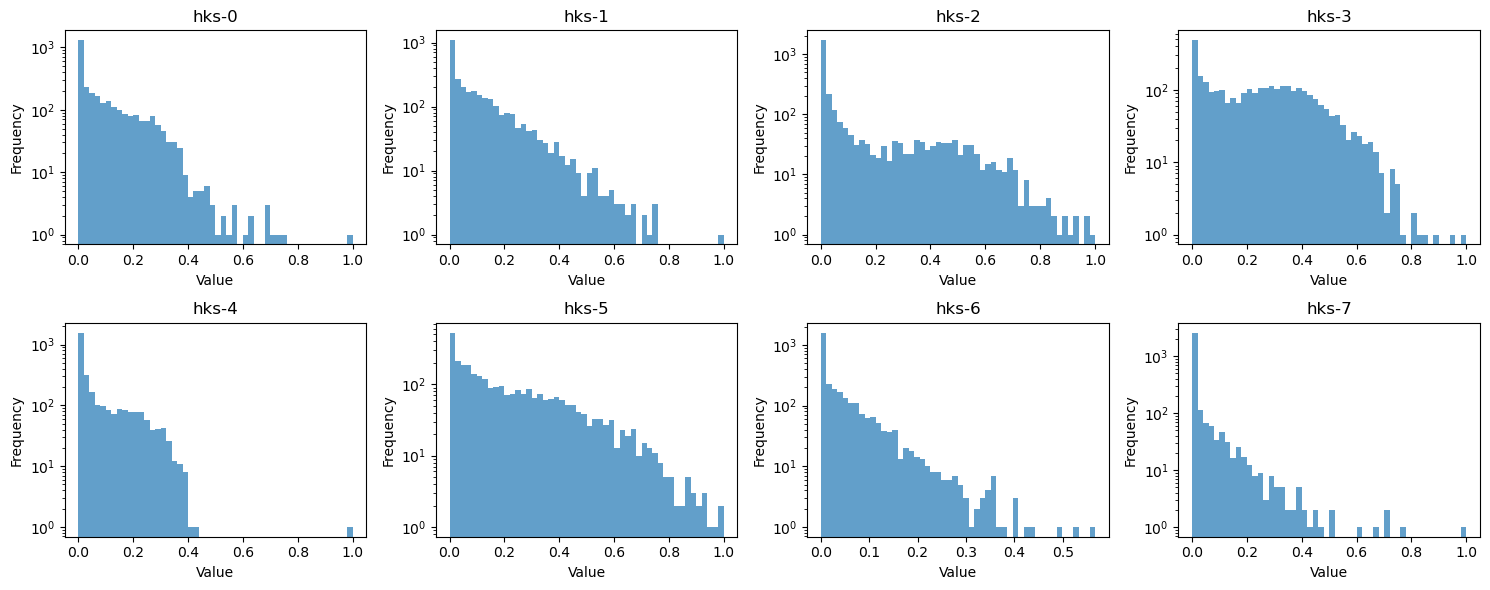

In [37]:
num_features = coeffs.shape[-1]
ncols = 4
nrows = (num_features + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 3 * nrows))
axes = axes.flatten()

for i in range(num_features):
    axes[i].hist(coeffs[:, 0, i], bins=50, alpha=0.7)
    axes[i].set_title(names[i])
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].set_yscale('log')  # Use logarithmic scale for better visibility

# Hide unused subplots
for j in range(num_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [38]:

# ---- Cell-type fractions from exclusive CSVs --------------------------------
# Each CSV has one row per cell; we filter to projected_to_mesh==True then
# compute the fraction of projected cells positive for each exclusive cell type.
# Only the needed columns are read to keep memory low.

DATASET_CSVS = {
    'main_dataset': 'Data/main_dataset/cell_features_class_with_projection_exclusive.csv',
    'sup_dataset':  'Data/sup_dataset/cell_features_class_with_projection_exclusive.csv',
}


def load_organoid_fractions(csv_path):
    with open(csv_path) as f:
        header = f.readline().strip().split(',')
    excl_cols = [c for c in header if c.endswith('_exclusive')]
    df = pd.read_csv(csv_path, usecols=['label_uid', 'projected_to_mesh'] + excl_cols)
    df = df[df['projected_to_mesh'].astype(str) == 'True']
    positive = (df[excl_cols] > 0).astype(float)
    positive['label_uid'] = df['label_uid'].values
    return positive.groupby('label_uid')[excl_cols].mean()

perc_dfs = {}
for ds, csv_path in DATASET_CSVS.items():
    print(f"Loading {ds} ...")
    perc_dfs[ds] = load_organoid_fractions(csv_path)

Loading main_dataset ...
Loading sup_dataset ...


/var/folders/5n/0rvnm9350db7gk5vdnj3tn6h0000gn/T/ipykernel_76738/1485920844.py:16: DtypeWarning: Columns (224) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path, usecols=['label_uid', 'projected_to_mesh'] + excl_cols)


In [39]:
# Intersection of cell types across datasets; strip suffix for friendly names
ct_cols   = sorted(set.intersection(*[set(df.columns) for df in perc_dfs.values()]))
col_names = [c.split('.')[0] for c in ct_cols]   # e.g. ['ABS','EC','EEPROG',...]
print('cell types:', col_names)

# Align percentages with filtered_ids.
# Use filtered_datasets from master to get the dataset name directly — avoids
# any fragile string splitting on ids that contain underscores in the dataset name.
percentages = np.zeros((len(filtered_ids), len(col_names)))
for i, (full_id, ds) in enumerate(zip(filtered_ids, filtered_datasets)):
    bare_uid = full_id[len(ds) + 1:]   # strip '{dataset}_' prefix
    if ds in perc_dfs and bare_uid in perc_dfs[ds].index:
        percentages[i] = perc_dfs[ds].loc[bare_uid, ct_cols].values

print(f'percentages: {percentages.shape}  zeros: {(percentages.sum(axis=1) == 0).sum()}')

cell types: ['ABS', 'EC', 'EEPROG', 'PANETH', 'SECPROG', 'STEM', 'TA']
percentages: (3056, 7)  zeros: 91


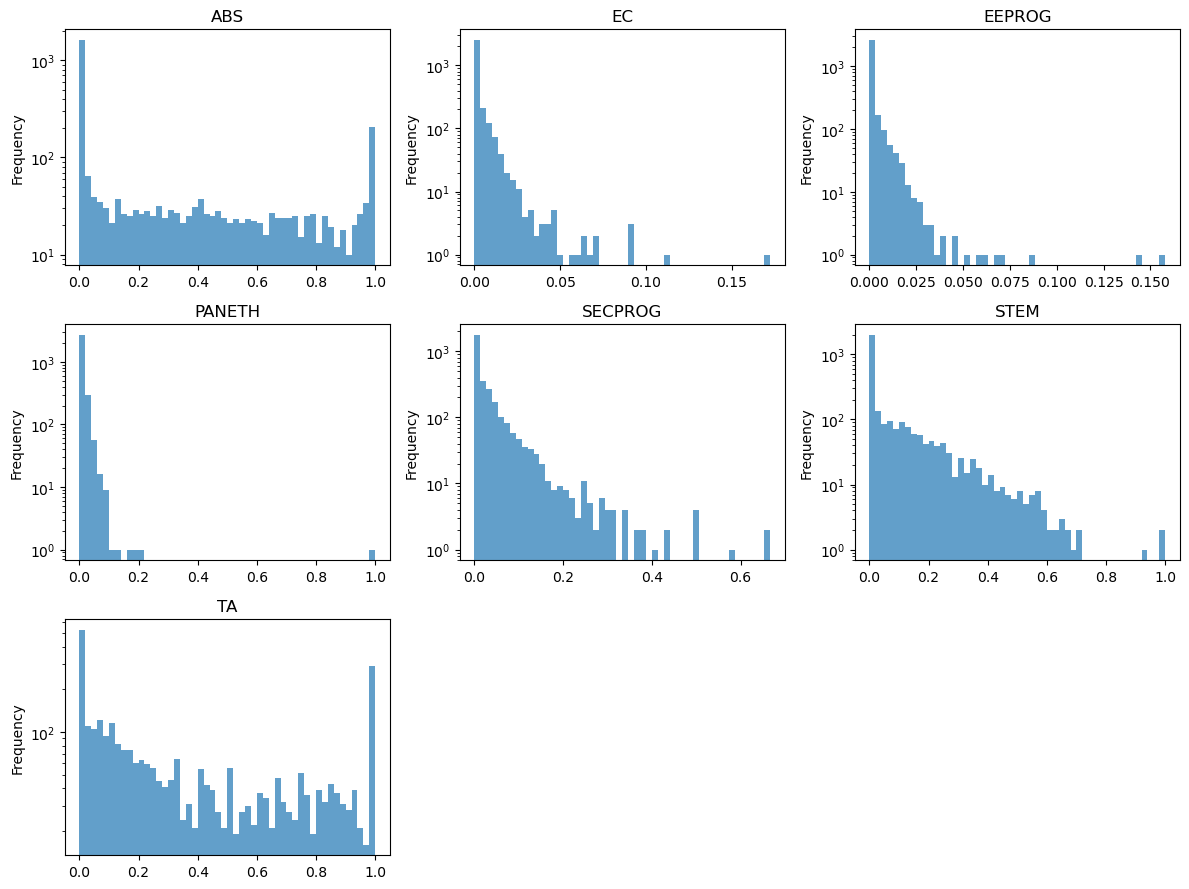

In [40]:
ncols = 3
nrows = (percentages.shape[1] + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 3 * nrows))
axes = axes.flatten()

for i in range(percentages.shape[1]):
    axes[i].hist(percentages[:, i], bins=50, alpha=0.7)
    axes[i].set_title(col_names[i])
    axes[i].set_ylabel('Frequency')
    axes[i].set_yscale('log')

for j in range(percentages.shape[1], len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [41]:
remainder = np.clip(1 - percentages.sum(axis=1, keepdims=True), 0, None)
percentages_full = np.hstack([percentages, remainder])

perc_fields = {f"perc_{n}": percentages[:, j] for j, n in enumerate(col_names)}

# 3-marker presence-absence combo: STEM / EC / PANETH (all in intersection)
COMBO_MARKERS = ['STEM', 'EC', 'PANETH']
if all(m in col_names for m in COMBO_MARKERS):
    fate_markers3 = {m: col_names.index(m) for m in COMBO_MARKERS}
    present = {m: percentages[:, j] > 0 for m, j in fate_markers3.items()}
    a, b, c = COMBO_MARKERS
    fate_combo = np.array([f"{a}{'+' if present[a][i] else '-'} "
                           f"{b}{'+' if present[b][i] else '-'} "
                           f"{c}{'+' if present[c][i] else '-'}"
                           for i in range(len(filtered_ids))])
    fate_combo_codes, fate_combo_uniques = pd.factorize(fate_combo)
    print(dict(zip(*np.unique(fate_combo, return_counts=True))))
else:
    print(f"Warning: not all combo markers {COMBO_MARKERS} found in {col_names}")
    fate_combo = np.array(["unknown"] * len(filtered_ids))
    fate_combo_codes = np.zeros(len(filtered_ids), dtype=int)
    fate_combo_uniques = np.array(["unknown"])

{'STEM+ EC+ PANETH+': 573, 'STEM+ EC+ PANETH-': 101, 'STEM+ EC- PANETH+': 366, 'STEM+ EC- PANETH-': 222, 'STEM- EC+ PANETH+': 39, 'STEM- EC+ PANETH-': 50, 'STEM- EC- PANETH+': 169, 'STEM- EC- PANETH-': 1536}


In [42]:
# subsample by timepoint

print("Unique timepoints:", np.unique(filtered_times))

# count how many samples fall into each timepoint
timepoint_counts = pd.Series(filtered_times).value_counts()
print("Timepoint counts:", timepoint_counts)



Unique timepoints: ['1p5' '2' '2p5' '3' '3p5' '4' '4p5' '4p5-more']
Timepoint counts: 4p5-more    503
3           461
4p5         428
1p5         376
2p5         364
4           343
3p5         306
2           275
Name: count, dtype: int64


In [43]:
# Subsample n_per_tp organoids per timepoint (stratified random sample)
samples_per_timepoint = [10, 10, 10, 10, 100, 500, 500, 600]  # Example: 50 samples for each timepoint
rng = np.random.default_rng(42)

keep_idx = np.sort(np.concatenate([
    rng.choice(np.where(filtered_times == t)[0],
               size=min(samples_per_timepoint[i], (filtered_times == t).sum()),
               replace=False)
    for (i, t) in enumerate(np.unique(filtered_times))
]))

filtered_ids       = filtered_ids[keep_idx]
filtered_datasets  = filtered_datasets[keep_idx]
filtered_times     = filtered_times[keep_idx]
filtered_areas     = filtered_areas[keep_idx]
l_cross_values     = l_cross_values[keep_idx]
filtered_hks       = filtered_hks[keep_idx]
hks_power_spectrum = hks_power_spectrum[keep_idx]
coeffs             = hks_power_spectrum
percentages        = percentages[keep_idx]
percentages_full   = percentages_full[keep_idx]
fate_combo         = fate_combo[keep_idx]
fate_combo_codes   = fate_combo_codes[keep_idx]
perc_fields        = {k: v[keep_idx] for k, v in perc_fields.items()}

print(f'Subsampled to {len(keep_idx)} organoids')
print(pd.Series(filtered_times).value_counts().sort_index())

Subsampled to 1414 organoids
1p5          10
2            10
2p5          10
3            10
3p5         100
4           343
4p5         428
4p5-more    503
Name: count, dtype: int64


In [44]:
def ilr_transform(X, eps=1e-6):
    X = np.asarray(X, dtype=float)
    X = X / X.sum(axis=1, keepdims=True)
    # multiplicative zero replacement: preserve sum=1
    zero_mask = X <= 0
    n_zeros = zero_mask.sum(axis=1, keepdims=True)
    X = np.where(zero_mask, eps, X * (1 - eps * n_zeros))
    # CLR
    log_x = np.log(X)
    clr = log_x - log_x.mean(axis=1, keepdims=True)
    # Helmert basis (D, D-1)
    D = X.shape[1]
    j = np.arange(1, D)
    a = 1.0 / np.sqrt(j * (j + 1))
    V = np.zeros((D, D - 1))
    for col, (jj, aa) in enumerate(zip(j, a)):
        V[:jj, col] = aa
        V[jj, col] = -jj * aa
    return clr @ V

percentages_ilr = ilr_transform(percentages_full)
print(percentages_ilr.shape)  # (N, D-1)

(1414, 7)


In [45]:
# --- initial (l-prior) weights — used only as the optimisation starting point
weights_vocab = np.sqrt(np.array([1, 1, 2, 0.01, 2, 1, 0.01, 2]))
weights_modes = np.ones(hks_power_spectrum.shape[1])
weights_modes[0] *= 2
weights_modes[1:10] *= np.arange(1, 10)  # weight by mode index (l)

# Curated near-isometric organoid groups — the old *manual* low-chamfer proxy.
# The weights are now learned from real chamfer (next cell); these groups are
# kept only as a sanity-check overlay in the embedding plots below.
uid_groups = [['main_dataset_day4p5_B06_51', 'main_dataset_day4p5-more_C03_120', 'sup_dataset_day4p5_B05_32'], 
     ['main_dataset_day4p5-more_C01_85', 'main_dataset_day4p5-more_C05_17', 'main_dataset_day4p5-more_C03_90', 'sup_dataset_day4p5_B02_8', 
      'main_dataset_day4p5_B06_49', 'sup_dataset_day4p5_B05_73', 
      'main_dataset_day4p5-more_C03_53', 'sup_dataset_day4p5_B02_27', 'sup_dataset_day4p5_B02_8'], 
      ['main_dataset_day4_A04_62', 'main_dataset_day4p5_B06_5', 'main_dataset_day4_B02_70', 
       'main_dataset_day4p5-more_C04_109', 'main_dataset_day4p5-more_C03_143', 'main_dataset_day4p5-more_C03_66', 
       'main_dataset_day4p5-more_C03_134', 'sup_dataset_day4p5_B03_91'], 
      ['main_dataset_day4_B01_43', 'main_dataset_day4p5_B06_126', 
       'main_dataset_day4_A05_6', 'main_dataset_day4_A03_13', 
       'main_dataset_day4p5_B06_38', 'main_dataset_day4p5-more_C04_87', 
       'sup_dataset_day4p5_B03_6', 'sup_dataset_day4p5_B02_83',
       'main_dataset_day4p5_A06_61'],
    #  ['main_dataset_day4p5_A06_20', 'sup_dataset_day4p5_B03_94', 
    #   'main_dataset_day4p5-more_C05_128', 'sup_dataset_day4p5_B03_48', 
    #   'main_dataset_day4p5-more_C04_3', 'main_dataset_day4p5-more_C06_8', 'main_dataset_day4p5-more_C03_25',
    #    'sup_dataset_day4p5_B02_66', 'main_dataset_day4p5-more_C03_23',
    #    'main_dataset_day4p5-more_C05_92']
]

In [46]:
# =====================================================================
# Chamfer-supervised weight learning + hand-picked group contrast
# ---------------------------------------------------------------------
# Two supervision sources shape the factorized weights_modes ⊗ weights_vocab:
#   (A) chamfer: among genuinely-close (small-chamfer) organoids, the
#       weighted HKS-spectrum distance should TRACK chamfer. One-sided —
#       large-chamfer pairs are excluded (unreliable / misaligned).
#   (B) uid_groups: the hand-picked groups are distinct categories, so make
#       each group TIGHT and DIFFERENT groups FAR — within-group distance
#       small vs between-group distance large.
#
# Objective:
#   L(w) = -Pearson(d_w, chamfer)_confident
#          + beta_group · mean_within_group(d_w) / mean_between_group(d_w)
#          + lambda_spread · spread(w)
#
# NB on (B): both numerator and denominator use ONLY the labelled organoids.
# The "negatives" are members of *other* hand-picked groups (genuinely different
# categories), never random unlabelled organoids — so this stays safe under the
# positive-unlabelled caveat (we never push an unlabelled same-group cell away).
# =====================================================================
from scipy.optimize import minimize
from scipy.stats import spearmanr, pearsonr
from itertools import combinations

M = hks_power_spectrum.shape[1]   # 15 modes
V = hks_power_spectrum.shape[2]   # 8 vocab

# ---- load chamfer matrix and align HKS rows to its id order ----------
ch        = np.load(f"{path}/chamfer_highcomplexity.npz", allow_pickle=True)
ch_ids    = ch['ids'].astype(str)
C         = ch['C']
id_to_row = {uid: i for i, uid in enumerate(filtered_ids)}
rows      = np.array([id_to_row[u] for u in ch_ids])
X         = hks_power_spectrum[rows]            # (n, M, V), aligned with C
n         = len(ch_ids)
iu        = np.triu_indices(n, k=1)
cham      = C[iu]

# ---- (A) confident chamfer pairs = smallest-chamfer fraction ---------
conf_pct = 5                                    # supervise on the closest this-% of pairs
conf_thr = np.percentile(cham, conf_pct)
conf     = cham < conf_thr
ci, cj   = iu[0][conf], iu[1][conf]
cc       = cham[conf]
Dc       = (X[ci] - X[cj]) ** 2                 # (P, M, V)
ccz      = (cc - cc.mean()) / cc.std()

# ---- (B) within-group pairs (close) vs between-group pairs (far) -----
# de-dupe ids within each group so a repeated uid can't make a zero self-pair
grp_rows = [list(dict.fromkeys(id_to_row[u] for u in grp if u in id_to_row))
            for grp in uid_groups]
w_i, w_j = [], []                               # within-group pairs
for rr in grp_rows:
    for a, b in combinations(rr, 2):
        w_i.append(a); w_j.append(b)
o_i, o_j = [], []                               # between-group pairs (different groups)
for p in range(len(grp_rows)):
    for q in range(p + 1, len(grp_rows)):
        for a in grp_rows[p]:
            for b in grp_rows[q]:
                o_i.append(a); o_j.append(b)
w_i, w_j, o_i, o_j = map(np.array, (w_i, w_j, o_i, o_j))
Dw = (hks_power_spectrum[w_i] - hks_power_spectrum[w_j]) ** 2     # within  (G, M, V)
Do = (hks_power_spectrum[o_i] - hks_power_spectrum[o_j]) ** 2     # between (H, M, V)
print(f"chamfer subset: {n} organoids | confident pairs (<p{conf_pct}={conf_thr:.3f}): {conf.sum()} "
      f"| within-group pairs: {len(w_i)} | between-group pairs: {len(o_i)}")

# ---- combined objective ---------------------------------------------
beta_group    = 0.1     # ↑ separates the groups more, at some cost to chamfer fidelity
lambda_spread = 0.01     # small ridge keeping weights from over-concentrating

def _logvar(log_w):
    c = log_w - log_w.mean()
    return c.var()

def _dist(Dsq, wm2, wv2):
    return np.sqrt(np.einsum('pmv,m,v->p', Dsq, wm2, wv2) + 1e-14)

def loss(params):
    wm2 = np.exp(2 * params[:M]); wv2 = np.exp(2 * params[M:])
    dc  = _dist(Dc, wm2, wv2)
    dcz = (dc - dc.mean()) / (dc.std() + 1e-12)
    corr        = (dcz * ccz).mean()                                       # (A) maximize
    group_ratio = _dist(Dw, wm2, wv2).mean() / _dist(Do, wm2, wv2).mean()  # (B) minimize
    return (-corr + beta_group * group_ratio
            + lambda_spread * (_logvar(params[:M]) + _logvar(params[M:])))

bounds = [(-4, 4)] * (M + V)                    # keep weights in a sane range (avoid overflow)
p_init = np.concatenate([np.log(weights_modes + 1e-8), np.log(weights_vocab + 1e-8)])
best = None
for seed in range(8):                           # multi-start; seed 0 = l-prior init
    p0 = p_init if seed == 0 else np.random.default_rng(seed).normal(0, 0.3, M + V)
    r  = minimize(loss, p0, method='L-BFGS-B', bounds=bounds, options={'maxiter': 400})
    if best is None or r.fun < best.fun:
        best = r

weights_modes_opt = np.exp(best.x[:M])
weights_vocab_opt = np.exp(best.x[M:])
weights_modes_opt *= np.linalg.norm(weights_modes) / np.linalg.norm(weights_modes_opt)
weights_vocab_opt *= np.linalg.norm(weights_vocab) / np.linalg.norm(weights_vocab_opt)

# ---- report: chamfer ordering + group separation, unweighted vs learned
def _spec(Dsq, wm, wv):
    return np.sqrt(np.einsum('pmv,m,v->p', Dsq, wm ** 2, wv ** 2) + 1e-14)
for nm, wm, wv in [('unweighted', np.ones(M), np.ones(V)),
                   ('learned',    weights_modes_opt, weights_vocab_opt)]:
    sp = spearmanr(_spec(Dc, wm, wv), cc).correlation
    gr = _spec(Dw, wm, wv).mean() / _spec(Do, wm, wv).mean()
    print(f"{nm:11s} chamfer-Spearman={sp:.3f}   within/between={gr:.3f}")
print(f"\nweights_modes_opt:\n{np.round(weights_modes_opt, 4)}")
print(f"\nweights_vocab_opt:\n{np.round(weights_vocab_opt, 4)}")

KeyError: 'main_dataset_day1p5_A04_128'

In [14]:
# Apply weights to the HKS power spectrum.
# Set LOAD_WEIGHTS to an .npz holding a (M, V) 'weights' array (e.g. from
# optimize_hks_weights.py, which learns a FULL per-feature weight) to use weights
# learned elsewhere; set to None to use the factorized weights from the cell above.
LOAD_WEIGHTS = False # "Data/hks_weights_full.npz"   

if LOAD_WEIGHTS:
    weights_full = np.load(LOAD_WEIGHTS)["weights"]            # (M, V)
    print(f"loaded weights {weights_full.shape} from {LOAD_WEIGHTS}")
else:
    weights_full = weights_modes_opt[:, None] * weights_vocab_opt[None, :]   # factorized

hks_scaled_opt = hks_power_spectrum * weights_full[np.newaxis, :, :]
hks_reshaped = hks_scaled_opt.reshape(hks_scaled_opt.shape[0], -1)

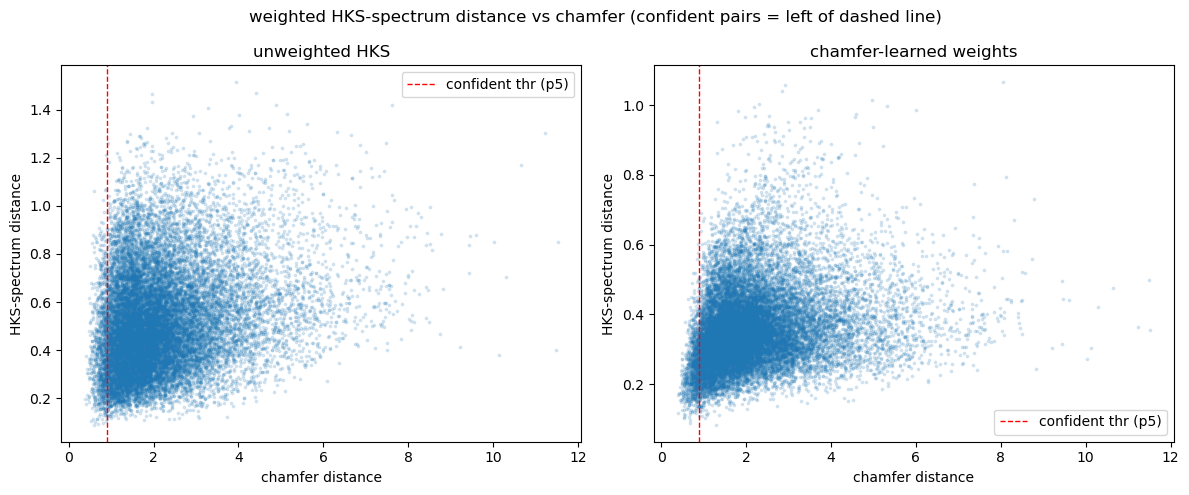

Spearman(spectrum, chamfer) on confident pairs (<p5):  unweighted 0.123  →  learned 0.307  (n=7771)


In [15]:
# --- Validation: weighted HKS-spectrum distance vs chamfer ------------------
# Left = unweighted HKS, right = chamfer-learned weights. In the confident
# (small-chamfer) regime — left of the dashed line — the learned weights should
# make spectrum distance rise more monotonically with chamfer. Large-chamfer
# pairs (right side) are intentionally unconstrained.
# Uses X, C, iu, ci, cj, cc, conf_thr, conf_pct from the optimisation cell.
cham_d = C[iu]
sel = np.random.default_rng(0).choice(len(cham_d), size=min(20000, len(cham_d)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, w_modes, w_vocab, ttl in [
        (axes[0], np.ones(M), np.ones(V), 'unweighted HKS'),
        (axes[1], weights_modes_opt, weights_vocab_opt, 'chamfer-learned weights')]:
    Xw_ = (X * w_modes[None, :, None] * w_vocab[None, None, :]).reshape(n, -1)
    d_  = np.linalg.norm(Xw_[iu[0][sel]] - Xw_[iu[1][sel]], axis=1)
    ax.scatter(cham_d[sel], d_, s=3, alpha=0.15)
    ax.axvline(conf_thr, color='r', ls='--', lw=1, label=f'confident thr (p{conf_pct})')
    ax.set_xlabel('chamfer distance'); ax.set_ylabel('HKS-spectrum distance')
    ax.set_title(ttl); ax.legend()
plt.suptitle('weighted HKS-spectrum distance vs chamfer (confident pairs = left of dashed line)')
plt.tight_layout(); plt.show()

# Spearman in the confident regime: unweighted vs learned
def _spec_all(wm, wv):
    Xw = (X * wm[None, :, None] * wv[None, None, :]).reshape(n, -1)
    return np.linalg.norm(Xw[ci] - Xw[cj], axis=1)
print(f"Spearman(spectrum, chamfer) on confident pairs (<p{conf_pct}):  "
      f"unweighted {spearmanr(_spec_all(np.ones(M), np.ones(V)), cc).correlation:.3f}  →  "
      f"learned {spearmanr(_spec_all(weights_modes_opt, weights_vocab_opt), cc).correlation:.3f}  "
      f"(n={conf.sum()})")

In [19]:
complexity_mask = l_cross_values >= 0

shape_features = hks_reshaped[complexity_mask]  # weighted-HKS shape representation
method = 'umap' 
if method == 'tsne':
    emb = TSNE(n_components=2, random_state=42, perplexity=40)
    hks_emb = emb.fit_transform(shape_features)
elif method == 'umap':
    hks_emb = umap.UMAP(n_components=2, random_state=42, n_neighbors=10, min_dist=1).fit_transform(shape_features)
elif method == 'phate':
    hks_emb = phate.PHATE(n_components=2, random_state=42, knn=5, t=10, gamma=0).fit_transform(shape_features)
elif method == 'pca':
    hks_emb = PCA(n_components=2).fit_transform(shape_features)
elif method == 'mds':
    from sklearn.manifold import MDS
    hks_emb = MDS(n_components=2, random_state=42, dissimilarity='euclidean').fit_transform(shape_features)

# compute explained variance 
if method == 'pca':
    pca = PCA(n_components=2)
    pca.fit(shape_features)
    explained_variance_ratio = pca.explained_variance_
    print(f"Explained variance ratio for PCA: {explained_variance_ratio}")
    print(pca.components_.shape)
    print(np.unravel_index(np.argmax(pca.components_, axis=1), (8, 15)))

/opt/homebrew/anaconda3/envs/scmpx/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [22]:

# ---- Cluster in the WEIGHTED-HKS space (the learned shape representation) ----
# Cluster on shape_features (the weighted HKS), NOT chamfer — chamfer is
# unreliable for the complex/misaligned organoids this representation exists for.
# Ward agglomerative merges nearest shapes bottom-up (a shape taxonomy); it allows
# uneven cluster sizes and is gentler than KMeans (which forces equal-size convex
# blobs). Switch CLUSTER_ALGO to try alternatives; keep n_shape_clusters < 10.
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.mixture import GaussianMixture

n_shape_clusters = 10          # < 10
CLUSTER_ALGO     = 'ward'     # 'ward' | 'complete' | 'gmm' | 'kmeans'

if CLUSTER_ALGO == 'ward':
    shape_clusters = AgglomerativeClustering(n_shape_clusters, linkage='ward').fit_predict(shape_features)
elif CLUSTER_ALGO == 'complete':
    shape_clusters = AgglomerativeClustering(n_shape_clusters, linkage='complete').fit_predict(shape_features)
elif CLUSTER_ALGO == 'gmm':
    shape_clusters = GaussianMixture(n_shape_clusters, covariance_type='full',
                                     random_state=42, n_init=5).fit_predict(shape_features)
else:
    shape_clusters = KMeans(n_shape_clusters, random_state=42, n_init=10).fit_predict(shape_features)

# relabel by descending size so colours are stable (biggest cluster = 0)
order = {c: r for r, c in enumerate(pd.Series(shape_clusters).value_counts().index)}
shape_clusters = np.array([order[c] for c in shape_clusters])
print(f"{CLUSTER_ALGO} on weighted-HKS: {n_shape_clusters} clusters | "
      f"sizes {pd.Series(shape_clusters).value_counts().sort_index().tolist()}")

# Per-point overlays so the saved embedding is self-contained for inspect_embedding.py:
#   uid_group : 0 = none, g+1 = membership in hand-picked group g
#   trusted   : 1 if the organoid was used to supervise the HKS weight learning
#               (in a confident small-chamfer pair) — informational only
m_ids = filtered_ids[complexity_mask]
m_pos = {u: i for i, u in enumerate(m_ids)}
uid_group_field = np.zeros(len(m_ids))
for gi, grp in enumerate(uid_groups):
    for u in grp:
        if u in m_pos:
            uid_group_field[m_pos[u]] = gi + 1
trusted_ids = set(ch_ids[ci]) | set(ch_ids[cj])
trusted_field = np.array([1.0 if u in trusted_ids else 0.0 for u in m_ids])

utils.save_embedding(emb_dir, "hks_full_emb", hks_emb, filtered_ids[complexity_mask], method,
                     times=filtered_times[complexity_mask], l_cross=l_cross_values[complexity_mask],
                     areas=filtered_areas[complexity_mask], shape_cluster=shape_clusters,
                     uid_group=uid_group_field, trusted=trusted_field,
                     **{k: v[complexity_mask] for k, v in perc_fields.items()})

ward on weighted-HKS: 10 clusters | sizes [563, 524, 356, 347, 304, 256, 246, 213, 166, 81]


'Data/embeddings/hks_full_emb.npz'

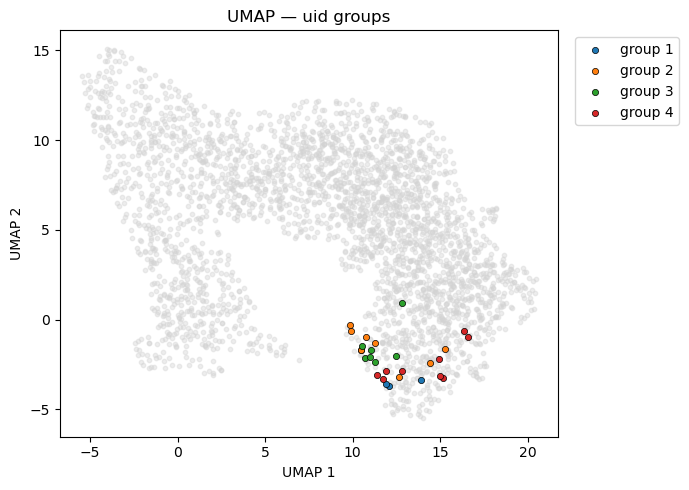

In [23]:
# plot the embedding colored by the uid groups
fig, ax = plt.subplots(figsize=(7, 5))
point_size = 10 

ax.scatter(hks_emb[:, 0], hks_emb[:, 1], color='lightgrey', alpha=0.4, s=point_size, zorder=1)

ids_masked = filtered_ids[complexity_mask]
cmap_groups = plt.get_cmap('tab10')

for g_idx, g in enumerate(uid_groups):
    color = cmap_groups(g_idx)
    first = True
    for uid in g:
        mask = ids_masked == uid
        if mask.any():
            ax.scatter(hks_emb[mask, 0], hks_emb[mask, 1], color=color, s=20,
                       zorder=3, edgecolors='black', linewidths=0.5,
                       label=f'group {g_idx + 1}' if first else '_nolegend_')
            first = False
        else:
            print(f"Warning: {uid} not in complexity_mask")

ax.set_title(f'{method.upper()} — uid groups')
ax.set_xlabel(f'{method.upper()} 1')
ax.set_ylabel(f'{method.upper()} 2')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

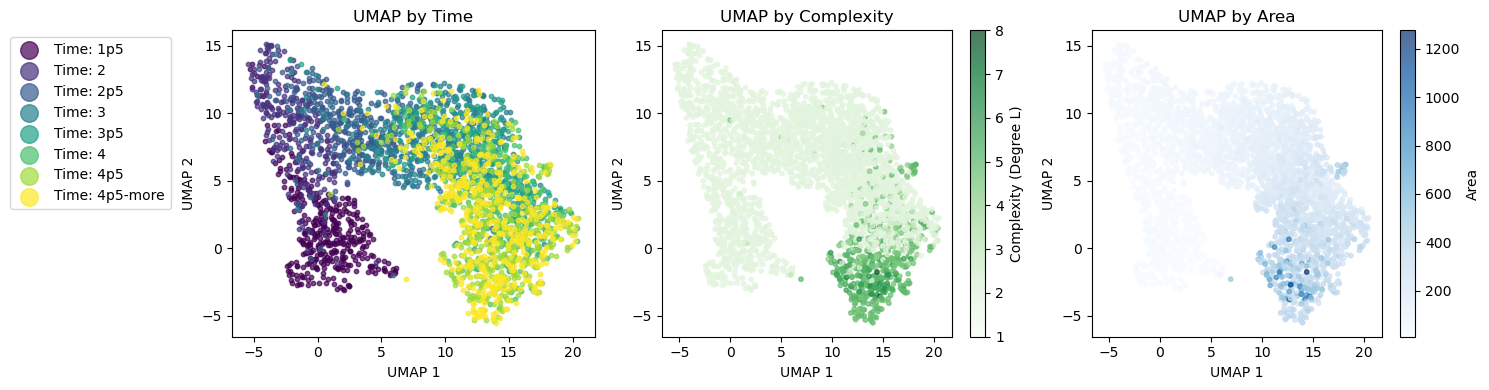

In [24]:
# Figure 1: Time and Complexity
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
point_size = 10

unique_times = np.unique(filtered_times)

cmap_time = plt.get_cmap('viridis')
for i, t in enumerate(unique_times):
    mask = filtered_times[complexity_mask] == t
    color = cmap_time(i / (len(unique_times) - 1))
    axes[0].scatter(hks_emb[mask, 0], hks_emb[mask, 1], color=color, alpha=0.7, s=point_size, label=f"Time: {t}")
axes[0].set_title(f'{method.upper()} by Time')
axes[0].set_xlabel(f'{method.upper()} 1')
axes[0].set_ylabel(f'{method.upper()} 2')
axes[0].legend(bbox_to_anchor=(-0.15, 1), loc='upper right', markerscale=4)

sc = axes[1].scatter(hks_emb[:, 0], hks_emb[:, 1], c=l_cross_values[complexity_mask], cmap='Greens', alpha=0.7, s=point_size, vmin=1, vmax=8)
axes[1].set_title(f'{method.upper()} by Complexity')
axes[1].set_xlabel(f'{method.upper()} 1')
axes[1].set_ylabel(f'{method.upper()} 2')
fig.colorbar(sc, ax=axes[1], label='Complexity (Degree L)')

sc = axes[2].scatter(hks_emb[:, 0], hks_emb[:, 1], c=filtered_areas[complexity_mask], cmap='Blues', alpha=0.7, s=point_size)
axes[2].set_title(f'{method.upper()} by Area')
axes[2].set_xlabel(f'{method.upper()} 1')
axes[2].set_ylabel(f'{method.upper()} 2')
fig.colorbar(sc, ax=axes[2], label='Area')

plt.tight_layout()
plt.show()

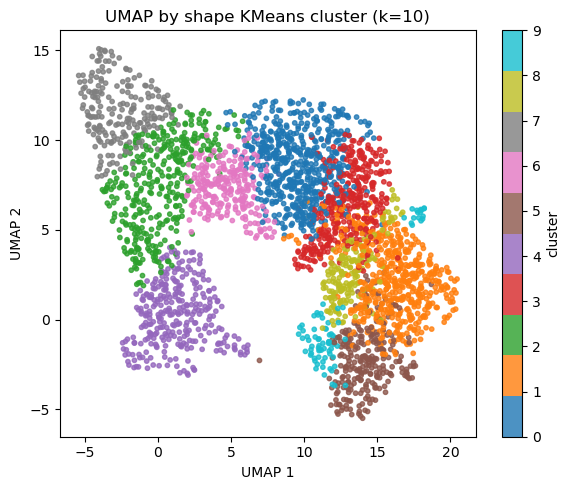

In [25]:
# Shape embedding coloured by KMeans cluster (clusters from original HKS coords)
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(hks_emb[:, 0], hks_emb[:, 1], c=shape_clusters, cmap='tab10',
                alpha=0.8, s=point_size)
ax.set_title(f'{method.upper()} by shape KMeans cluster (k={n_shape_clusters})')
ax.set_xlabel(f'{method.upper()} 1'); ax.set_ylabel(f'{method.upper()} 2')
cbar = fig.colorbar(sc, ax=ax, ticks=range(n_shape_clusters), label='cluster')
plt.tight_layout()
plt.show()

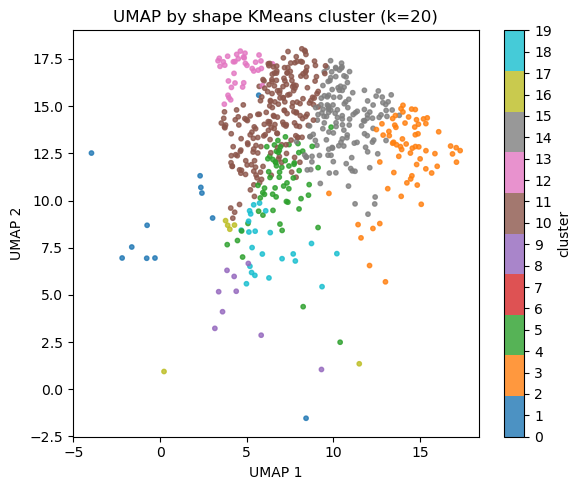

In [260]:
# just show high complexity organoids (l_cross >= 2.5) in the embedding
complexity_mask = l_cross_values >= 2.5

fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(hks_emb[complexity_mask, 0], hks_emb[complexity_mask, 1], c=shape_clusters[complexity_mask], cmap='tab10',
                alpha=0.8, s=point_size)
ax.set_title(f'{method.upper()} by shape KMeans cluster (k={n_shape_clusters})')
ax.set_xlabel(f'{method.upper()} 1'); ax.set_ylabel(f'{method.upper()} 2')
cbar = fig.colorbar(sc, ax=ax, ticks=range(n_shape_clusters), label='cluster')
plt.tight_layout()
plt.show()

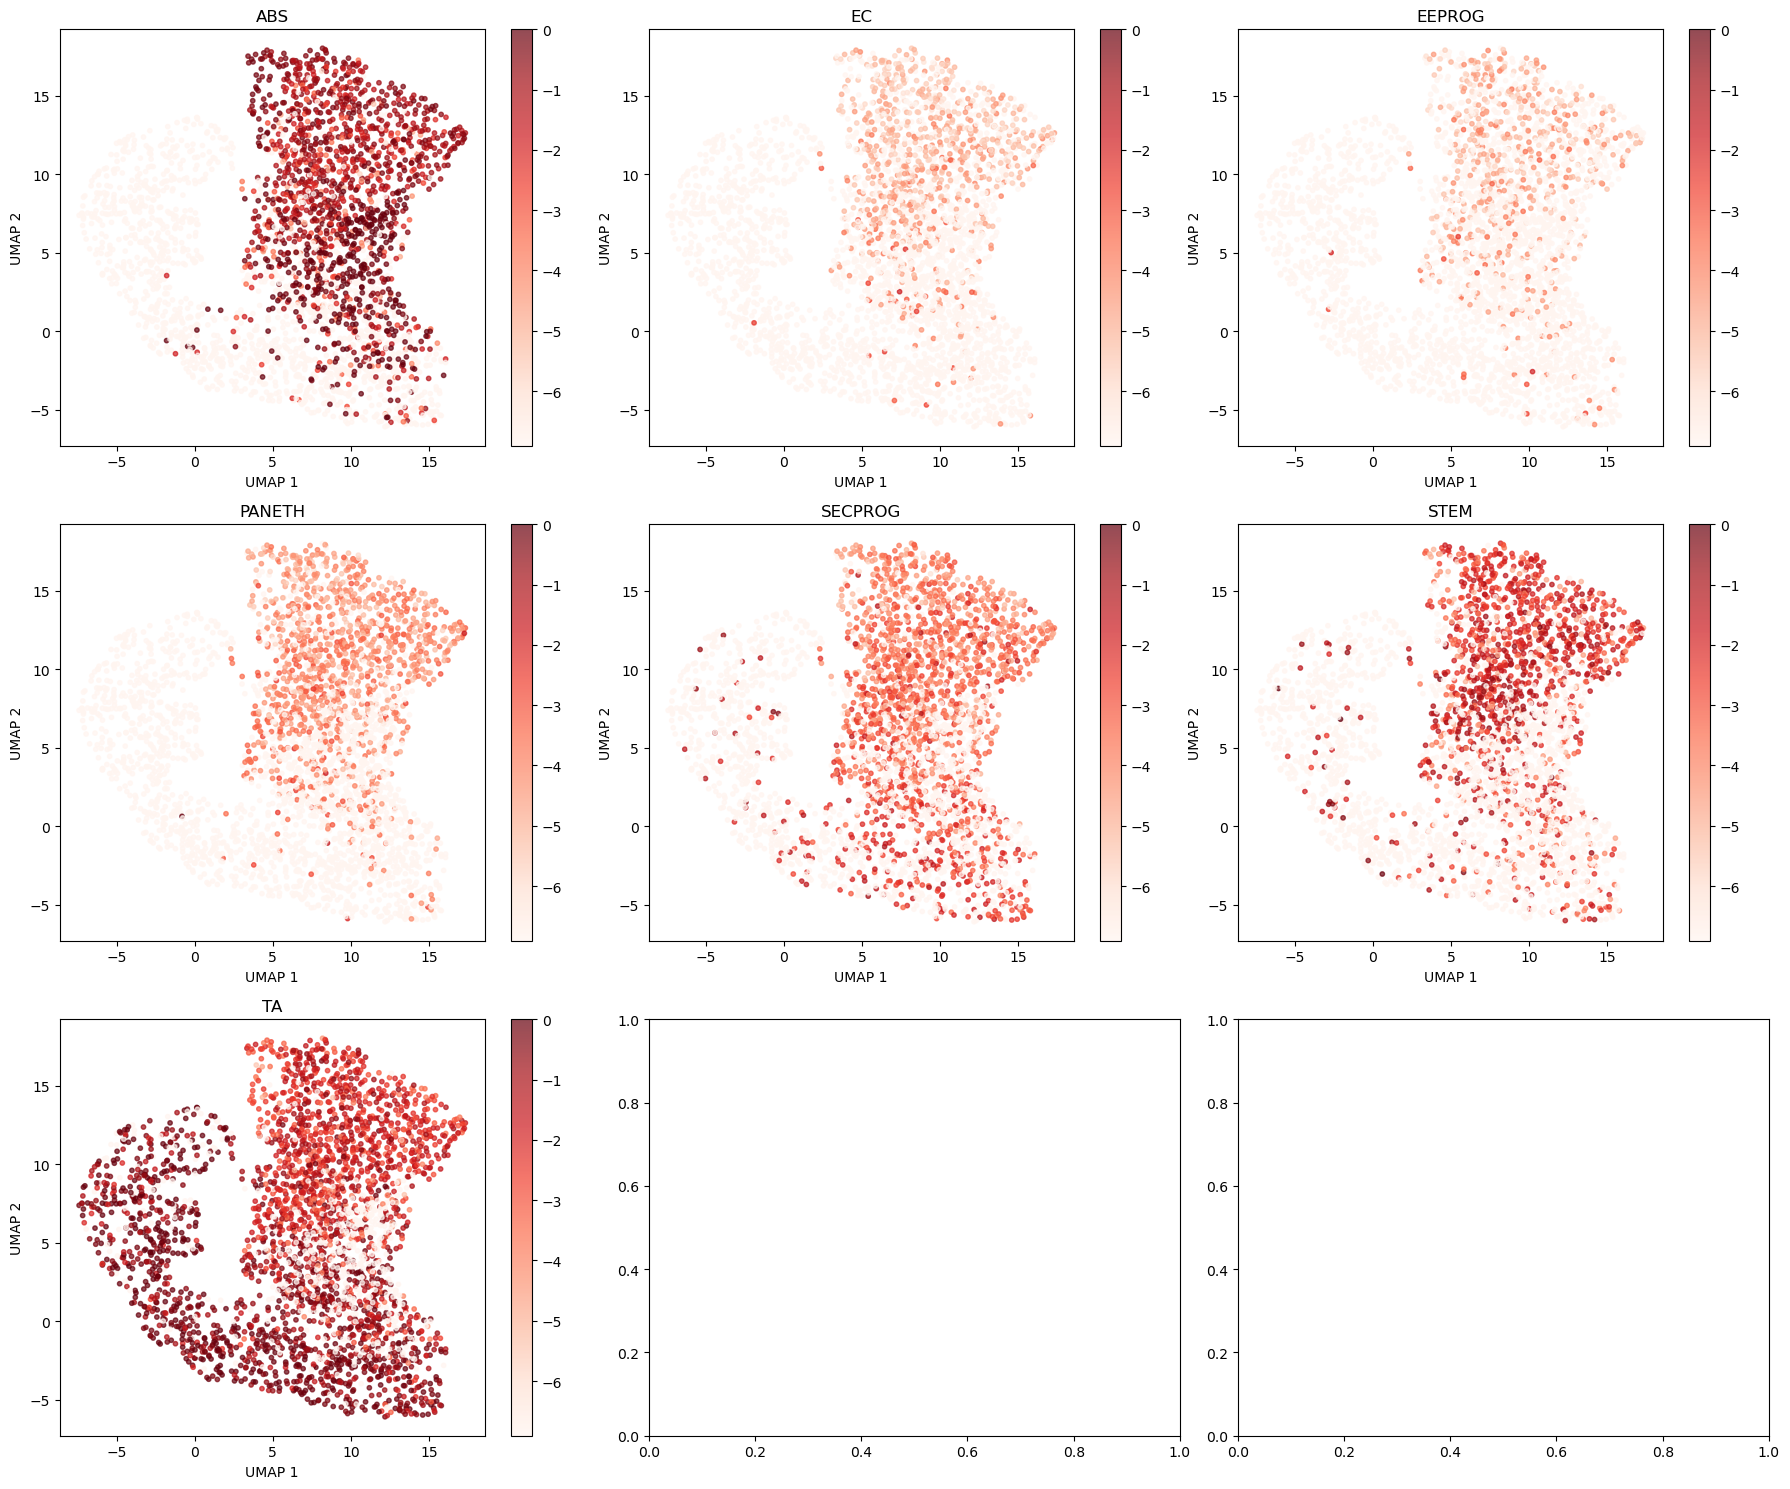

In [247]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

vmin = np.log(percentages_full + 1e-3).min()
vmax = np.log(percentages_full + 1e-3).max()

for i in range(percentages_full.shape[1]-1):
    sc = axes[i].scatter(hks_emb[:, 0], hks_emb[:, 1], c=np.log(percentages_full[complexity_mask, i]+1e-3), cmap='Reds', alpha=0.7, s=point_size, vmin=vmin, vmax=vmax)
    axes[i].set_title(col_names[i])
    axes[i].set_xlabel(f'{method.upper()} 1')
    axes[i].set_ylabel(f'{method.upper()} 2')
    fig.colorbar(sc, ax=axes[i])

plt.tight_layout()
plt.show()

In [ ]:

# plot the embedding colored by the uid groups
fig, ax = plt.subplots(figsize=(7, 5))

ax.scatter(hks_emb[:, 0], hks_emb[:, 1], color='lightgrey', alpha=0.4, s=point_size, zorder=1)

ids_masked = filtered_ids[complexity_mask]
cmap_groups = plt.get_cmap('tab10')

for g_idx, g in enumerate(uid_groups):
    color = cmap_groups(g_idx)
    first = True
    for uid in g:
        mask = ids_masked == uid
        if mask.any():
            ax.scatter(hks_emb[mask, 0], hks_emb[mask, 1], color=color, s=100,
                       zorder=3, edgecolors='black', linewidths=0.5,
                       label=f'group {g_idx + 1}' if first else '_nolegend_')
            first = False
        else:
            print(f"Warning: {uid} not in complexity_mask")

ax.set_title(f'{method.upper()} — uid groups')
ax.set_xlabel(f'{method.upper()} 1')
ax.set_ylabel(f'{method.upper()} 2')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


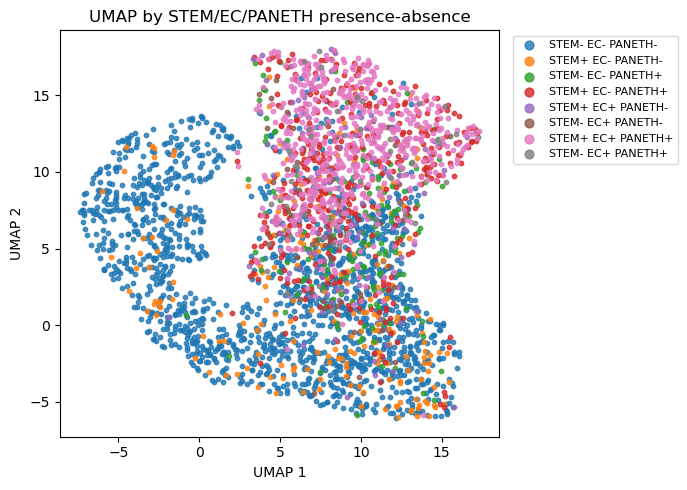

In [248]:
# Shape embedding coloured by STEM/EC/PANETH presence-absence combo
fig, ax = plt.subplots(figsize=(7, 5))
codes_m = fate_combo_codes[complexity_mask]
cmap_combo = plt.get_cmap('tab10')
for code in np.unique(fate_combo_codes):
    mask = codes_m == code
    if not mask.any():
        continue
    ax.scatter(hks_emb[mask, 0], hks_emb[mask, 1], color=cmap_combo(code % 10),
               alpha=0.8, s=point_size, label=fate_combo_uniques[code])
ax.set_title(f'{method.upper()} by {"/".join(COMBO_MARKERS)} presence-absence')
ax.set_xlabel(f'{method.upper()} 1'); ax.set_ylabel(f'{method.upper()} 2')
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', markerscale=2, fontsize=8)
plt.tight_layout()
plt.show()

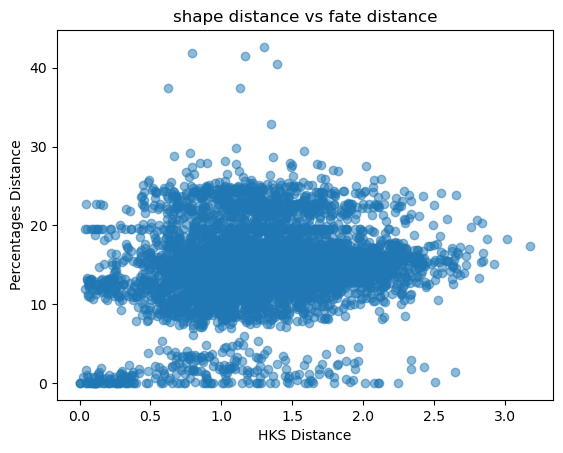

In [249]:
# randomly select 1000 pairs of samples to compute distances
num_samples = hks_reshaped.shape[0]
num_pairs = 5000
sample_indices = np.random.choice(num_samples, size=(num_pairs, 2), replace=True)

hks_dist = np.linalg.norm(hks_reshaped[sample_indices[:, 0]]- hks_reshaped[sample_indices[:, 1]], axis=1)
perc_dist = np.linalg.norm(percentages_ilr[sample_indices[:, 0]]- percentages_ilr[sample_indices[:, 1]], axis=1)

mean_hks_dist = np.mean(hks_dist)
mean_perc_dist = np.mean(perc_dist)

plt.plot(hks_dist.flatten(), perc_dist.flatten(), 'o', alpha=0.5)
plt.xlabel('HKS Distance')
plt.ylabel('Percentages Distance')
plt.title('shape distance vs fate distance')
plt.show()  

hks_normalised = hks_reshaped  / mean_hks_dist
percentages_normalised = percentages_ilr / mean_perc_dist

X scores: (3065, 2), Y scores: (3065, 2)


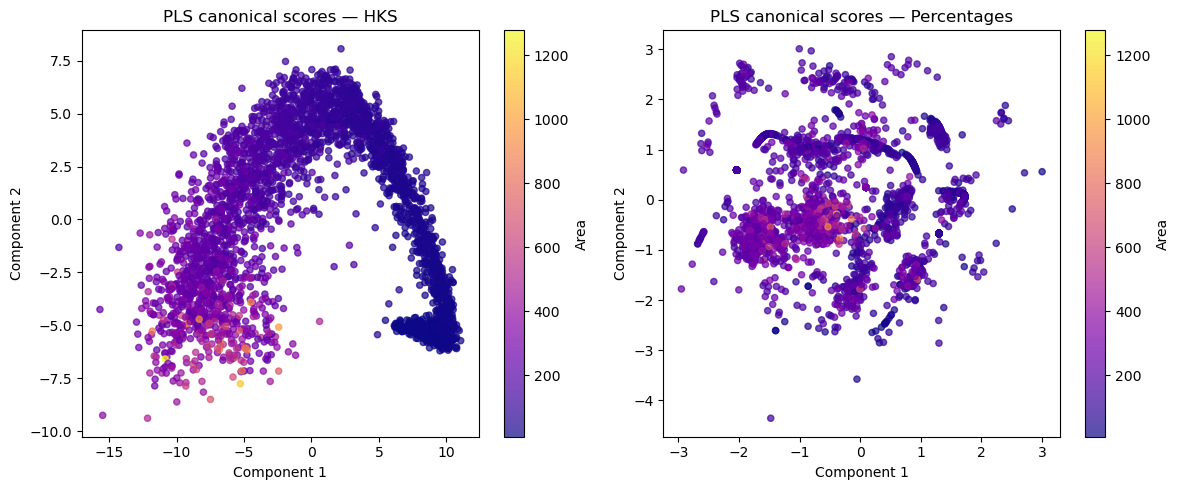

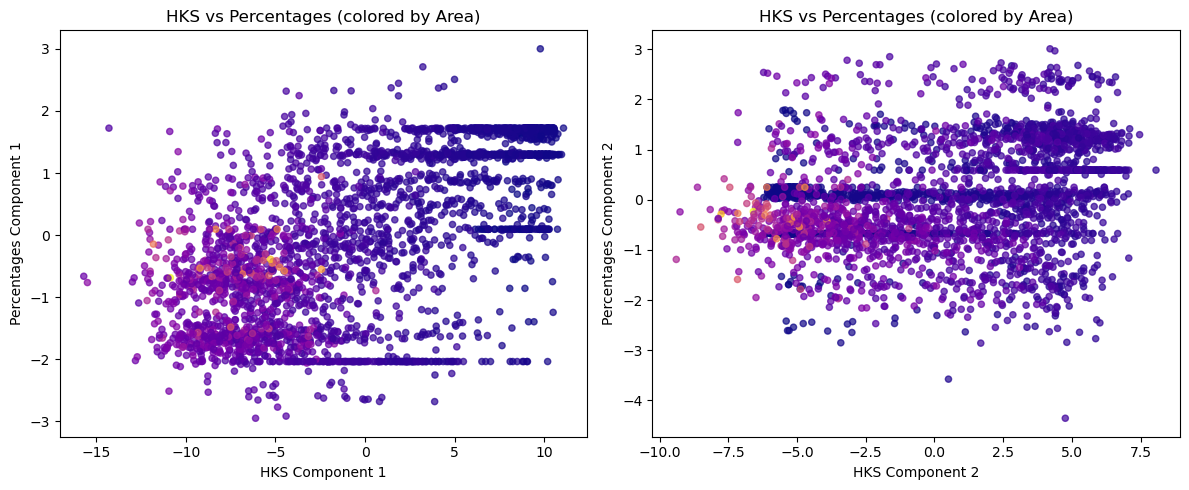

In [250]:
X_pls = hks_normalised
Y_pls = percentages_normalised

pls = PLSCanonical(n_components=2, max_iter=1000)
pls.fit(X_pls, Y_pls)
X_c, Y_c = pls.transform(X_pls, Y_pls)
print(f"X scores: {X_c.shape}, Y scores: {Y_c.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, scores, label in zip(axes, [X_c, Y_c], ['HKS', 'Percentages']):
    sc = ax.scatter(scores[:, 0], scores[:, 1], c=filtered_areas, cmap='plasma', alpha=0.7, s=20)
    ax.set_title(f'PLS canonical scores — {label}')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    fig.colorbar(sc, ax=ax, label='Area')
plt.tight_layout()
plt.show()

# plot hks component 1 vs percentages component 1

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i in range(2): 
    axes[i].scatter(X_c[:, i], Y_c[:, i], c=filtered_areas, cmap='plasma', alpha=0.7, s=20)
    axes[i].set_xlabel(f'HKS Component {i+1}')
    axes[i].set_ylabel(f'Percentages Component {i+1}')
    axes[i].set_title(f'HKS vs Percentages (colored by Area)')
plt.tight_layout()
plt.show()

In [251]:
area_normalised = (filtered_areas - np.min(filtered_areas)) / (np.max(filtered_areas) - np.min(filtered_areas))
X  = np.concatenate((hks_normalised, percentages_normalised, area_normalised[:, np.newaxis]), axis=1) 

method = 'umap' 
if method == 'tsne':
    emb = TSNE(n_components=2, random_state=42)
    X_emb = emb.fit_transform(X)
elif method == 'umap':
    X_emb = umap.UMAP(n_components=2, random_state=10, n_neighbors=20, min_dist=1).fit_transform(X)
elif method == 'phate':
    X_emb = phate.PHATE(n_components=2, random_state=42, knn=50, t=30).fit_transform(X)
elif method == 'pca':
    X_emb = PCA(n_components=2).fit_transform(X)

utils.save_embedding(emb_dir, "X_emb", X_emb, filtered_ids, method,
                     times=filtered_times, l_cross=l_cross_values, areas=filtered_areas,
                     **perc_fields)

/opt/homebrew/anaconda3/envs/scmpx/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


'Data/embeddings/X_emb.npz'

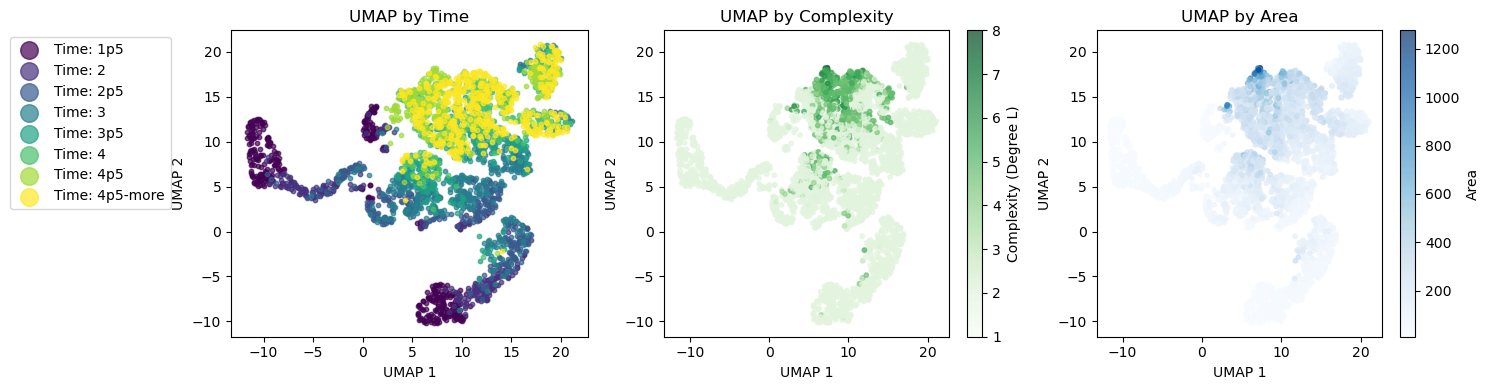

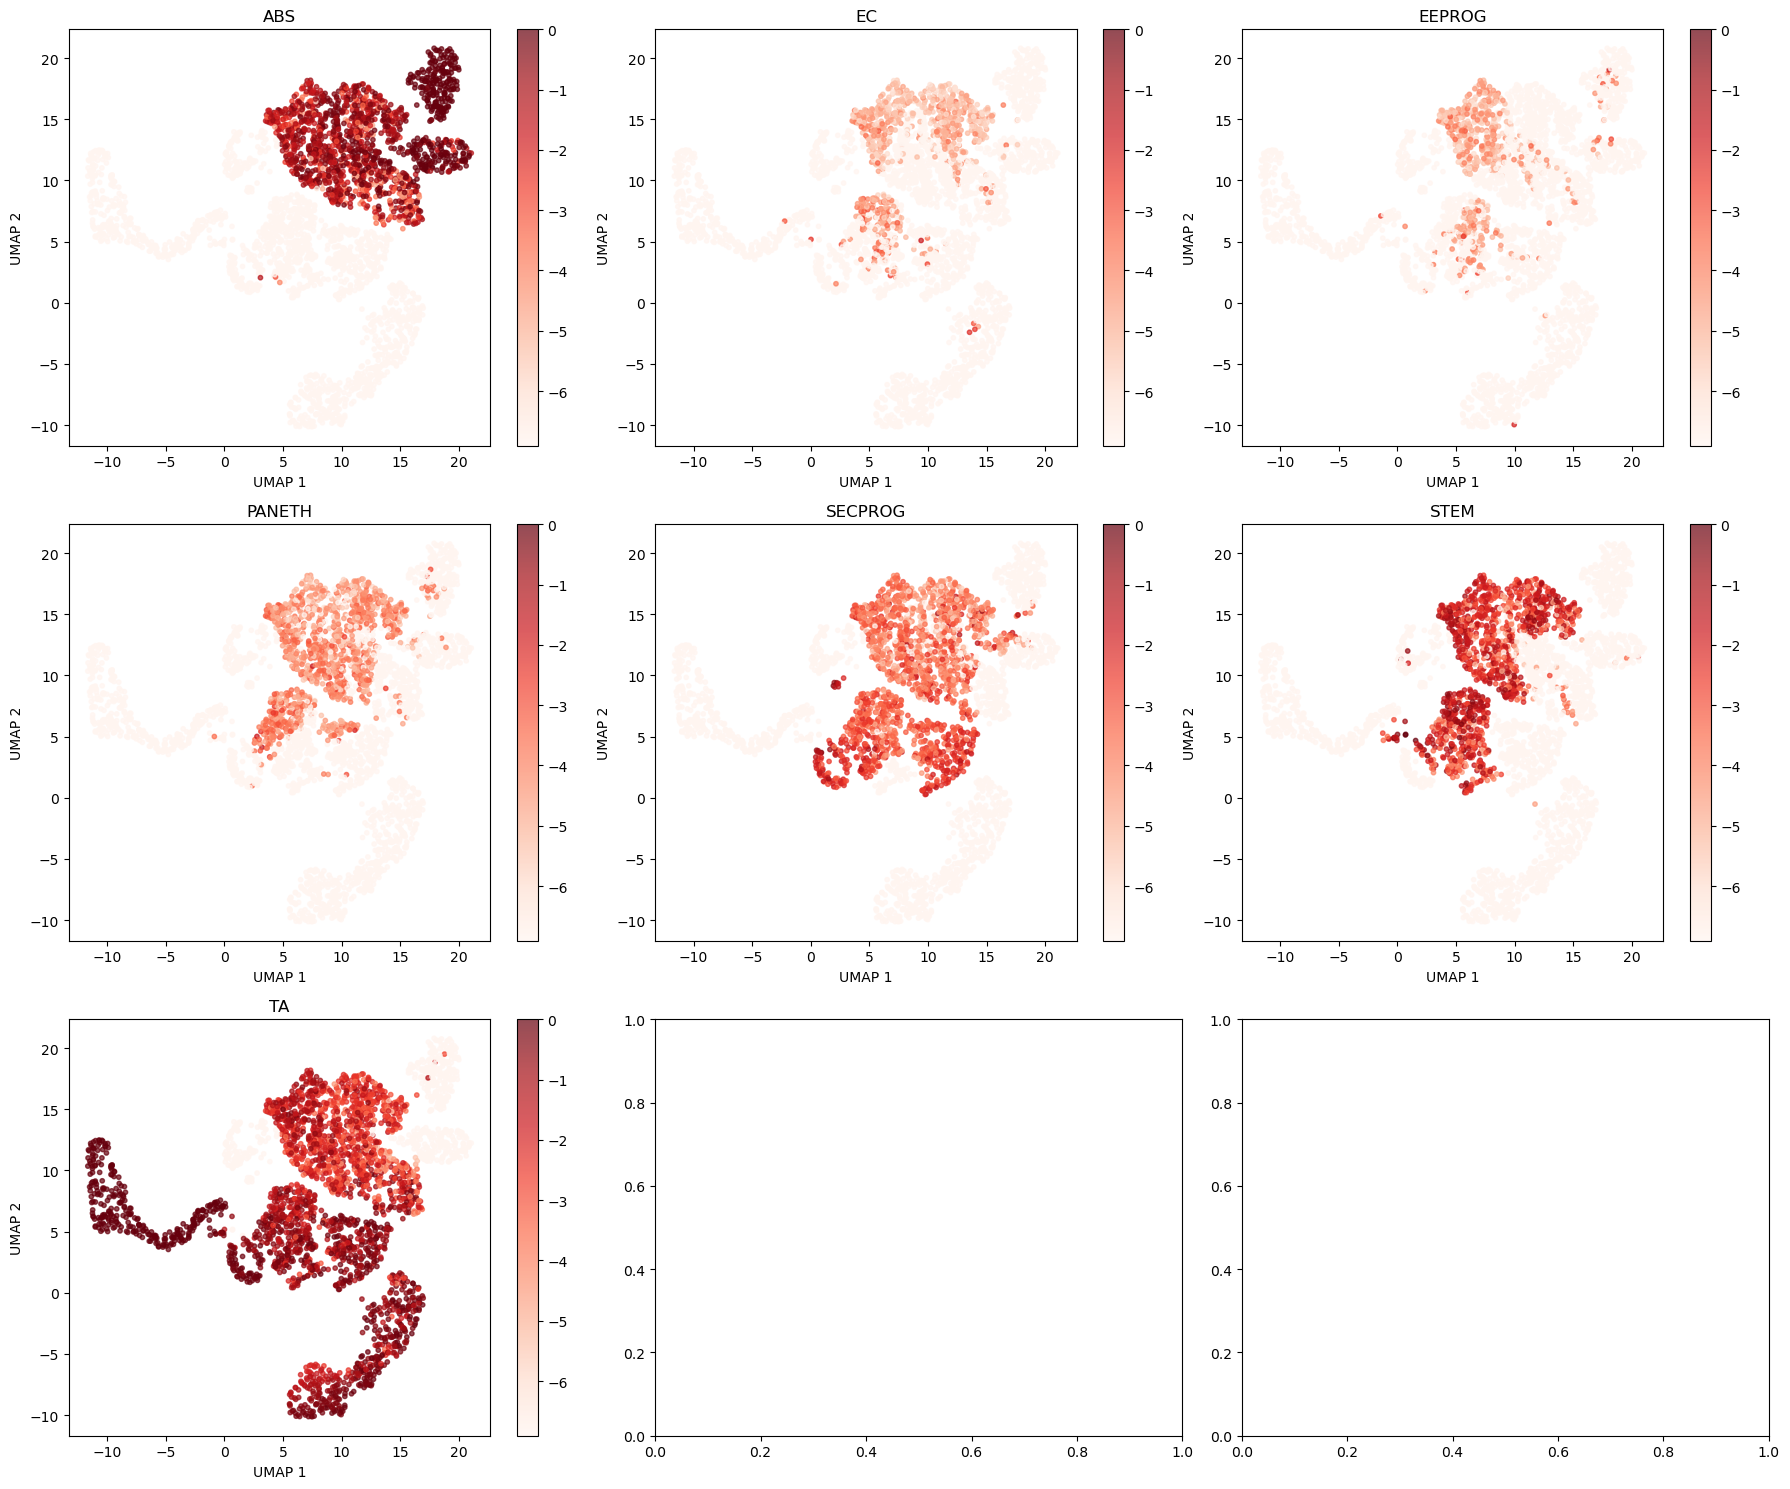

In [252]:
unique_times = np.unique(filtered_times)
point_size = 10

# Figure 1: Time and Complexity
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cmap_time = plt.get_cmap('viridis')
for i, t in enumerate(unique_times):
    mask = filtered_times == t
    color = cmap_time(i / (len(unique_times) - 1))
    axes[0].scatter(X_emb[mask, 0], X_emb[mask, 1], color=color, alpha=0.7, s=point_size, label=f"Time: {t}")
axes[0].set_title(f'{method.upper()} by Time')
axes[0].set_xlabel(f'{method.upper()} 1')
axes[0].set_ylabel(f'{method.upper()} 2')
axes[0].legend(bbox_to_anchor=(-0.15, 1), loc='upper right', markerscale=4)

sc = axes[1].scatter(X_emb[:, 0], X_emb[:, 1], c=l_cross_values, cmap='Greens', alpha=0.7, s=point_size, vmin=1, vmax=8)
axes[1].set_title(f'{method.upper()} by Complexity')
axes[1].set_xlabel(f'{method.upper()} 1')
axes[1].set_ylabel(f'{method.upper()} 2')
fig.colorbar(sc, ax=axes[1], label='Complexity (Degree L)')

sc = axes[2].scatter(X_emb[:, 0], X_emb[:, 1], c=filtered_areas, cmap='Blues', alpha=0.7, s=point_size)
axes[2].set_title(f'{method.upper()} by Area')
axes[2].set_xlabel(f'{method.upper()} 1')
axes[2].set_ylabel(f'{method.upper()} 2')
fig.colorbar(sc, ax=axes[2], label='Area')

plt.tight_layout()
plt.show()

# Figure 2: Fate marker percentages (3x3)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

vmin = np.log(percentages_full + 1e-3).min()
vmax = np.log(percentages_full + 1e-3).max()

for i in range(percentages_full.shape[1]-1):
    sc = axes[i].scatter(X_emb[:, 0], X_emb[:, 1], c=np.log(percentages_full[:, i]+1e-3), cmap='Reds', alpha=0.7, s=point_size, vmin=vmin, vmax=vmax)
    axes[i].set_title(col_names[i])
    axes[i].set_xlabel(f'{method.upper()} 1')
    axes[i].set_ylabel(f'{method.upper()} 2')
    fig.colorbar(sc, ax=axes[i])

plt.tight_layout()
plt.show()